In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
lld1_file = "LLD1_vb-1e-8_20260511_162646.csv"
lld2_file = "LLD2_vb-1e-8_20260511_162646.csv"

lld1 = pd.read_csv(lld1_file)
lld2 = pd.read_csv(lld2_file)

In [3]:
lld1.head()

,pc_timestamp,arduino_ms,analog_value
0,1.778513e+09,20,471
1,1.778513e+09,40,469
2,1.778513e+09,60,471
3,1.778513e+09,80,467
4,1.778513e+09,100,471


In [4]:
lld2.head()

,pc_timestamp,arduino_ms,analog_value
0,1.778513e+09,20,507
1,1.778513e+09,40,509
2,1.778513e+09,60,506
3,1.778513e+09,80,508
4,1.778513e+09,100,506


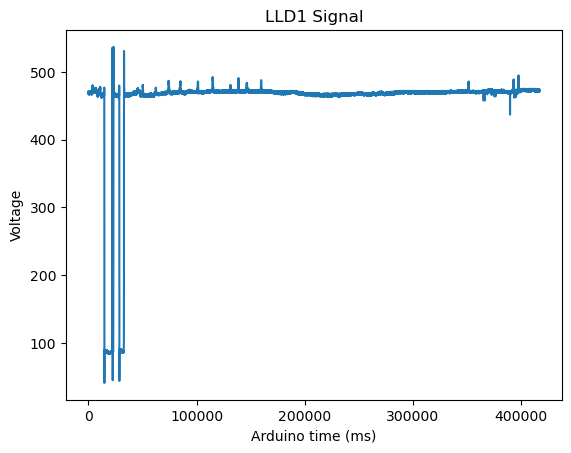

In [17]:
plt.figure()

plt.plot(lld1["arduino_ms"], lld1["analog_value"])

plt.title("LLD1 Signal")
plt.xlabel("Arduino time (ms)")
plt.ylabel("Voltage")

plt.show()

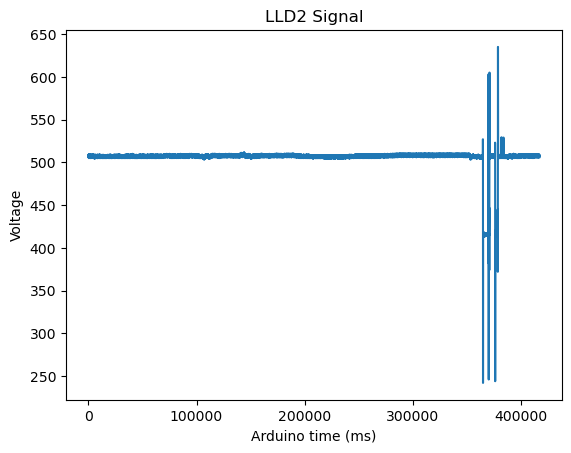

In [19]:
plt.figure()

plt.plot(lld2["arduino_ms"], lld2["analog_value"])

plt.title("LLD2 Signal")
plt.xlabel("Arduino time (ms)")
plt.ylabel("Voltage")

plt.show()

Note - the below are attempts at event capture

In [8]:
# Create time axes

lld1["time_s"] = (
    lld1["arduino_ms"] - lld1["arduino_ms"].iloc[0]
) / 1000

lld2["time_s"] = (
    lld2["arduino_ms"] - lld2["arduino_ms"].iloc[0]
) / 1000

In [9]:
threshold = 350

In [10]:
lld1_gas = lld1[lld1["analog_value"] < threshold]
lld2_gas = lld2[lld2["analog_value"] < threshold]

In [11]:
lld1_first_gas = lld1_gas["time_s"].iloc[0]
lld1_last_gas = lld1_gas["time_s"].iloc[-1]

lld2_first_gas = lld2_gas["time_s"].iloc[0]
lld2_last_gas = lld2_gas["time_s"].iloc[-1]

lld1_start = lld1_first_gas - 2
lld1_end = lld1_last_gas + 2

lld2_start = lld2_first_gas - 2
lld2_end = lld2_last_gas + 2

In [12]:
lld1_trimmed = lld1[
    (lld1["time_s"] >= lld1_start) &
    (lld1["time_s"] <= lld1_end)
].copy()

lld2_trimmed = lld2[
    (lld2["time_s"] >= lld2_start) &
    (lld2["time_s"] <= lld2_end)
].copy()

In [13]:
lld1_trimmed["event_time_s"] = (
    lld1_trimmed["time_s"] - lld1_first_gas
)

lld2_trimmed["event_time_s"] = (
    lld2_trimmed["time_s"] - lld2_first_gas
)

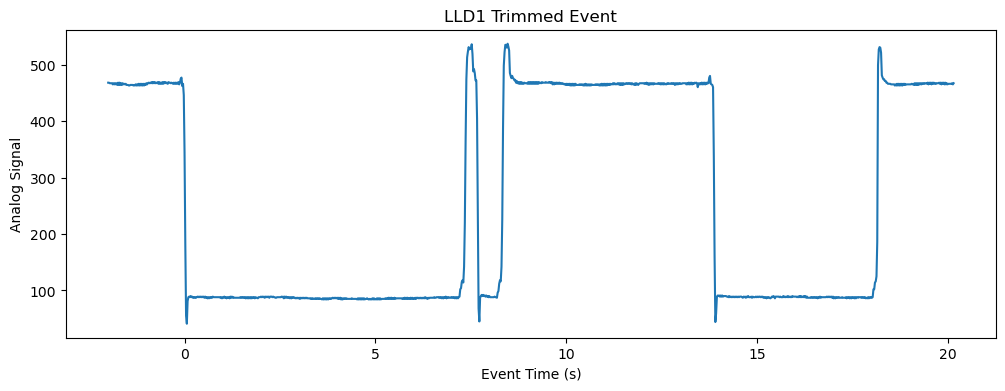

In [14]:
plt.figure(figsize=(12,4))

plt.plot(
    lld1_trimmed["event_time_s"],
    lld1_trimmed["analog_value"]
)

plt.xlabel("Event Time (s)")
plt.ylabel("Analog Signal")
plt.title("LLD1 Trimmed Event")

plt.show()

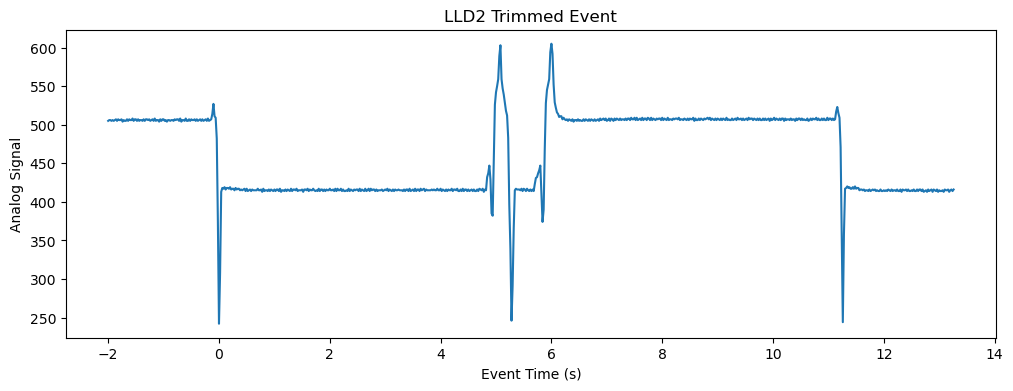

In [15]:
plt.figure(figsize=(12,4))

plt.plot(
    lld2_trimmed["event_time_s"],
    lld2_trimmed["analog_value"]
)

plt.xlabel("Event Time (s)")
plt.ylabel("Analog Signal")
plt.title("LLD2 Trimmed Event")

plt.show()

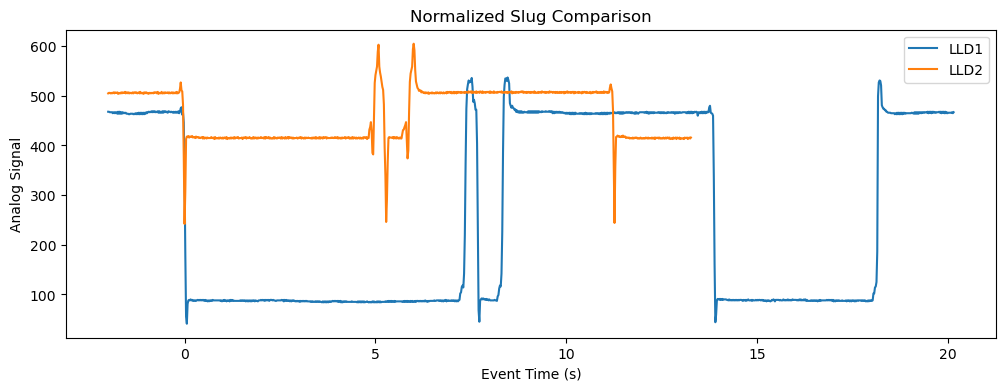

In [16]:
plt.figure(figsize=(12,4))

plt.plot(
    lld1_trimmed["event_time_s"],
    lld1_trimmed["analog_value"],
    label="LLD1"
)

plt.plot(
    lld2_trimmed["event_time_s"],
    lld2_trimmed["analog_value"],
    label="LLD2"
)

plt.xlabel("Event Time (s)")
plt.ylabel("Analog Signal")
plt.title("Normalized Slug Comparison")

plt.legend()

plt.show()